# 16 · Prior optimisation for the seven Energy BVARs

This notebook selects prior hyperparameters **model by model** for the production
Energy BVAR-SV-outlier engine.

## Methodological position

Giannone, Lenza and Primiceri (GLP, *Prior Selection for Vector Autoregressions*)
treat prior tightness parameters as hyperparameters and select them through their
posterior / marginal likelihood. In a conjugate Normal-Inverse-Wishart BVAR, the
marginal likelihood is available in closed form.

The production Energy model used here is **not conjugate**: it contains stochastic
volatility, a contemporaneous matrix \(A\), latent outliers, stability truncation,
optional Durbin-Koopman data augmentation, and deterministic regressors for
electricity. Therefore the closed-form GLP marginal likelihood is **not** used as
if it were the marginal likelihood of this richer model.

Instead, this notebook keeps the GLP principle — let predictive performance select
prior informativeness — and applies it to the **actual production sampler** using
recursive pseudo-out-of-sample density forecasts.

For candidate prior \(\gamma\), expanding-window origins \(o\), and forecast horizon
\(h\), the notebook estimates the exact model using information available through
origin \(o\), generates posterior predictive draws, and evaluates the realization
\(y_{o+h}\).

Primary criterion:

\[
\text{CRPS}(\gamma)
=
\frac{1}{N}\sum_{o,h}
\left[
E|X_{o,h}^{(\gamma)}-y_{o+h}|
-\frac12E|X_{o,h}^{(\gamma)}-X_{o,h}^{\prime(\gamma)}|
\right].
\]

Lower CRPS is better. RMSE / MAE and the predictive log score are reported as
secondary diagnostics.

**Important:** this is pseudo-real-time, not a real-time-vintage evaluation. Each
origin truncates the selected processed vintage and never uses future observations
in estimation. Deterministic future seasonal dummies are allowed because they are
known by construction.

## Search strategy

To control computational cost, priors are searched in blocks:

1. Minnesota tightness: \(\lambda_1,\lambda_2\)
2. Lag decay: \(\lambda_3\)
3. Constant prior scale: \(\lambda_4\)
4. Standardised contemporaneous-\(A\) variance
5. Stochastic-volatility prior: annualised \(\phi\) variance + df
6. Initial log-volatility variance \(h_0\)
7. Outlier interval + outlier-prior strength, both expressed in calendar years

Each block holds the previously selected blocks fixed. This is a transparent
block-coordinate search, not a claim of a globally exact optimum.

The notebook never writes to the production run registry. Optimisation outputs are
saved under `results/prior_optimisation/`.

## 0 · Setup

The notebook imports the current production engine from `src/model`.

The uploaded implementation already provides:
- explicit monthly / weekly model frequency;
- frequency-aware outlier prior calibration;
- scale-normalised prior variance for the contemporaneous matrix `A`;
- selectable `linear` or `dk` missing-data treatment;
- deterministic monthly dummies for electricity.

In [2]:
1+1

2

In [3]:
from __future__ import annotations

from dataclasses import asdict, replace
from pathlib import Path
from itertools import product
from typing import Mapping, Sequence
import hashlib
import json
import math
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import logsumexp

# ---------------------------------------------------------------------
# Project root
# ---------------------------------------------------------------------
def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "src" / "model").is_dir() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not find a project root containing src/model and data."
    )

PROJECT_ROOT = find_project_root()
MODEL_DIR = PROJECT_ROOT / "src" / "model"
if str(MODEL_DIR) not in sys.path:
    sys.path.insert(0, str(MODEL_DIR))

from energy_bvar_model import (
    BVARSVOPriorConfig,
    SamplerConfig,
    default_bvar_svo_prior_config,
    forecast_bvar_sv_outlier,
    outlier_mean_frequency_from_years,
    outlier_prior_observations_from_years,
    periods_per_year,
    run_energy_bvar,
)
from energy_bvar_pipeline import (
    CANONICAL_MODEL_IDS,
    build_panel,
    model_spec,
    resolve_common_vintage,
)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("MODEL_DIR    :", MODEL_DIR)

PROJECT_ROOT: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy
MODEL_DIR    : C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\src\model


## 1 · Global optimisation configuration

Three run modes are supplied:

- `screen`: cheap first-pass search;
- `confirm`: more origins and more Gibbs draws;
- `final`: production-size Gibbs settings for a small set of finalists.

The intended workflow is **screen → confirm → final**, rather than running the
entire grid immediately with 6,000 Gibbs sweeps.

Missing-value treatment is configurable model by model. `"baseline"` resolves to
the production `ModelSpec` setting. Use `"linear"` or `"dk"` to override it.

In [4]:
# Use a complete common vintage by default.
VINTAGE = resolve_common_vintage(project_root=PROJECT_ROOT)

RUN_MODES = {
    "screen": {
        "reps": 1_200,
        "burn": 600,
        "thin": 1,
        "n_origins_monthly": 6,
        "n_origins_weekly": 6,
        "origin_step_monthly": 1,
        "origin_step_weekly": 4,
        "forecast_draws": 300,
    },
    "confirm": {
        "reps": 3_000,
        "burn": 1_500,
        "thin": 1,
        "n_origins_monthly": 12,
        "n_origins_weekly": 12,
        "origin_step_monthly": 1,
        "origin_step_weekly": 4,
        "forecast_draws": 500,
    },
    "final": {
        "reps": 6_000,
        "burn": 3_000,
        "thin": 1,
        "n_origins_monthly": 18,
        "n_origins_weekly": 18,
        "origin_step_monthly": 1,
        "origin_step_weekly": 4,
        "forecast_draws": 1_000,
    },
}

# Calendar-comparable evaluation horizons.
MODEL_HORIZONS = {
    "monthly": (1, 3, 6),
    "weekly": (1, 4, 13),
}

# "baseline" -> use ModelSpec.missing_data_method.
# Change any entry to "linear" or "dk" if desired.
MISSING_METHOD = {
    model_id: "baseline"
    for model_id in CANONICAL_MODEL_IDS
}

# Primary scoring variable. None means use panel.target.
SCORE_VARIABLE_OVERRIDE = {
    model_id: None
    for model_id in CANONICAL_MODEL_IDS
}

CACHE_ROOT = PROJECT_ROOT / "results" / "prior_optimisation" / str(VINTAGE)
CACHE_ROOT.mkdir(parents=True, exist_ok=True)

print("VINTAGE   :", VINTAGE)
print("CACHE_ROOT:", CACHE_ROOT)
pd.DataFrame(
    [
        {
            "model_id": m,
            "label": model_spec(m).label,
            "frequency": model_spec(m).frequency,
            "p": model_spec(m).p,
            "missing_baseline": model_spec(m).missing_data_method,
        }
        for m in CANONICAL_MODEL_IDS
    ]
)

VINTAGE   : 20260816
CACHE_ROOT: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\results\prior_optimisation\20260816


,model_id,label,frequency,p,missing_baseline
0,gas,Natural gas,monthly,12,linear
1,electricity,Electricity,monthly,12,linear
2,heat_energy,Heat energy,monthly,12,linear
3,solid_fuels,Solid fuels,monthly,12,linear
4,car_fuels_petrol,Car fuels - petrol,weekly,24,dk
5,car_fuels_diesel,Car fuels - diesel,weekly,24,dk
6,liquid_fuels,Liquid fuels - heating oil,weekly,24,dk


## 2 · Prior parameterisation

Two choices are expressed in **calendar time**:

- outlier mean interval, in years;
- outlier-prior strength, in years.

The helper converts those years to model periods automatically:
48 months vs 208 weeks for a four-year interval, and 120 months vs 520 weeks
for ten years of prior strength.

For stochastic volatility, the search can use an **annualised innovation
variance**:

\[
\phi_{	ext{annual}} = m_f \phi_{	ext{period}},
\]

where \(m_f=12\) monthly and \(m_f=52\) weekly. This makes the search grid
comparable in calendar time, while the production sampler still receives the
per-period `phi_prior_mean` it expects.

In [5]:
def prior_with_overrides(
    frequency: str,
    *,
    base: BVARSVOPriorConfig | None = None,
    overrides: Mapping[str, float] | None = None,
) -> BVARSVOPriorConfig:
    cfg = default_bvar_svo_prior_config(frequency) if base is None else base
    values = dict(overrides or {})

    converted = {}

    if "outlier_interval_years" in values:
        converted["outlier_mean_frequency"] = outlier_mean_frequency_from_years(
            values.pop("outlier_interval_years"), frequency
        )

    if "outlier_prior_strength_years" in values:
        converted["outlier_prior_observations"] = (
            outlier_prior_observations_from_years(
                values.pop("outlier_prior_strength_years"), frequency
            )
        )

    if "phi_annual_variance" in values:
        annual = float(values.pop("phi_annual_variance"))
        converted["phi_prior_mean"] = annual / periods_per_year(frequency)

    converted.update(values)
    out = replace(cfg, **converted)
    out.validate()
    return out


def prior_calendar_view(cfg: BVARSVOPriorConfig, frequency: str) -> dict:
    ppy = periods_per_year(frequency)
    return {
        **asdict(cfg),
        "phi_annual_variance": float(cfg.phi_prior_mean * ppy),
        "outlier_interval_years": float(
            1.0 / cfg.outlier_mean_frequency / ppy
        ),
        "outlier_prior_strength_years": float(
            cfg.outlier_prior_observations / ppy
        ),
    }


for frequency in ("monthly", "weekly"):
    baseline = default_bvar_svo_prior_config(frequency)
    view = prior_calendar_view(baseline, frequency)
    print(
        frequency,
        "| outlier interval years =", view["outlier_interval_years"],
        "| prior strength years =", view["outlier_prior_strength_years"],
        "| phi annual variance =", view["phi_annual_variance"],
    )

monthly | outlier interval years = 4.0 | prior strength years = 10.0 | phi annual variance = 0.24
weekly | outlier interval years = 4.0 | prior strength years = 10.0 | phi annual variance = 1.04


## 3 · Proper scoring rules

`CRPS` is the primary objective because it evaluates the complete predictive
distribution without requiring a Gaussian approximation.

The log predictive score is estimated from the one-dimensional ensemble with a
Gaussian kernel. It is useful as a secondary diagnostic, but the ranking defaults
to mean CRPS.

In [6]:
def crps_ensemble(draws: np.ndarray, actual: float) -> float:
    x = np.asarray(draws, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0 or not np.isfinite(actual):
        return np.nan

    first = np.mean(np.abs(x - actual))
    xs = np.sort(x)
    n = len(xs)
    # 0.5 * E|X-X'| using the exact empirical-distribution formula.
    coeff = 2 * np.arange(1, n + 1) - n - 1
    half_pairwise = np.sum(coeff * xs) / (n * n)
    return float(first - half_pairwise)


def ensemble_log_score(draws: np.ndarray, actual: float) -> float:
    x = np.asarray(draws, dtype=float)
    x = x[np.isfinite(x)]
    if x.size < 5 or not np.isfinite(actual):
        return np.nan

    sd = float(np.std(x, ddof=1))
    q25, q75 = np.quantile(x, [0.25, 0.75])
    robust = float((q75 - q25) / 1.349)
    scale_candidates = [v for v in (sd, robust) if np.isfinite(v) and v > 0]
    scale = min(scale_candidates) if scale_candidates else max(abs(float(np.mean(x))), 1.0) * 1e-6
    bandwidth = max(0.9 * scale * (len(x) ** (-1 / 5)), np.finfo(float).eps)

    z = (actual - x) / bandwidth
    log_kernel = -0.5 * z**2 - math.log(bandwidth) - 0.5 * math.log(2 * math.pi)
    return float(logsumexp(log_kernel) - math.log(len(x)))


def point_forecast_metrics(draws: np.ndarray, actual: float) -> dict:
    x = np.asarray(draws, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0 or not np.isfinite(actual):
        return {
            "predictive_mean": np.nan,
            "predictive_median": np.nan,
            "error_mean": np.nan,
            "abs_error_mean": np.nan,
            "sq_error_mean": np.nan,
        }
    mean = float(np.mean(x))
    median = float(np.median(x))
    err = mean - float(actual)
    return {
        "predictive_mean": mean,
        "predictive_median": median,
        "error_mean": err,
        "abs_error_mean": abs(err),
        "sq_error_mean": err**2,
    }

## 4 · Expanding-window origins

Origins are selected from the end of the processed sample, subject to:
- enough observations to estimate the VAR;
- a finite realized target at all requested horizons;
- no use of future endogenous values in the training sample.

For weekly models, the default screen evaluates every fourth week to keep the
computation tractable.

In [7]:
def resolve_missing_method(model_id: str) -> str:
    requested = str(MISSING_METHOD.get(model_id, "baseline")).lower()
    if requested == "baseline":
        return str(model_spec(model_id).missing_data_method)
    if requested not in {"linear", "dk"}:
        raise ValueError(f"{model_id}: missing method must be baseline, linear, or dk.")
    return requested


def candidate_origins(
    panel,
    *,
    horizons: Sequence[int],
    n_origins: int,
    step: int,
) -> pd.DatetimeIndex:
    dates = pd.DatetimeIndex(panel.levels.index)
    target = panel.target
    max_h = int(max(horizons))

    # Conservative minimum. The sampler itself applies the definitive guards.
    min_train = max(int(panel.p) + 36, 72 if panel.frequency == "monthly" else 156)

    candidates = []
    for pos in range(min_train - 1, len(dates) - max_h):
        origin = dates[pos]
        ok = True
        for h in horizons:
            realized_date = dates[pos + int(h)]
            value = panel.levels.loc[realized_date, target]
            if pd.isna(value) or not np.isfinite(float(value)):
                ok = False
                break
        if ok:
            candidates.append(origin)

    if not candidates:
        raise ValueError(f"{panel.model_id}: no valid pseudo-OOS origins.")

    selected = list(reversed(candidates))[:: max(int(step), 1)][: int(n_origins)]
    selected = sorted(selected)
    return pd.DatetimeIndex(selected, name="origin")

## 5 · One pseudo-OOS fit

This function calls the **actual production** `run_energy_bvar` engine on a
truncated expanding window. It does not use `run_component`, because
`run_component` is designed for the full production vintage and persistence.

Electricity seasonal dummies are split consistently into estimation and forecast
segments. Future stochastic outliers remain enabled so that the density score
evaluates the same predictive mechanism used in production.

In [8]:
def _future_dates_from_panel(panel, origin: pd.Timestamp, H: int) -> pd.DatetimeIndex:
    dates = pd.DatetimeIndex(panel.levels.index)
    loc = dates.get_loc(pd.Timestamp(origin))
    if isinstance(loc, slice):
        loc = loc.stop - 1
    out = dates[loc + 1 : loc + 1 + int(H)]
    if len(out) != int(H):
        raise ValueError("Forecast horizon extends beyond available evaluation data.")
    return pd.DatetimeIndex(out, name="date")


def fit_and_score_origin(
    *,
    panel,
    prior_config: BVARSVOPriorConfig,
    origin: pd.Timestamp,
    horizons: Sequence[int],
    mode: Mapping,
    missing_data_method: str,
    seed: int,
    score_variable: str,
) -> list[dict]:
    H = int(max(horizons))
    train_levels = panel.levels.loc[:origin].copy()
    train_exog = None if panel.exog is None else panel.exog.reindex(train_levels.index).copy()

    sampler = SamplerConfig(
        reps=int(mode["reps"]),
        burn=int(mode["burn"]),
        thin=int(mode["thin"]),
        seed=int(seed),
        progress_every=0,
    )

    result = run_energy_bvar(
        levels=train_levels,
        model_id=panel.model_id,
        vintage=str(panel.vintage),
        p=int(panel.p),
        variables=list(panel.variables),
        frequency=str(panel.frequency),
        exog=train_exog,
        exog_prior_scale=(
            10.0 if panel.exog_prior_scale is None else float(panel.exog_prior_scale)
        ),
        prior_config=prior_config,
        sampler_config=sampler,
        missing_data_method=missing_data_method,
        code_version="prior_optimisation_notebook_v1",
    )

    future_dates = _future_dates_from_panel(panel, origin, H)
    future_exog = None
    if panel.exog is not None:
        future_exog = panel.exog.reindex(future_dates).copy()

    fc = forecast_bvar_sv_outlier(
        result,
        H=H,
        future_exog=future_exog,
        n_draws=min(int(mode["forecast_draws"]), int(result["n_draws"])),
        simulate_future_outliers=True,
        seed=int(seed) + 10_000,
    )

    j = list(fc["variables"]).index(score_variable)
    rows = []
    for h in horizons:
        idx = int(h) - 1
        date = pd.Timestamp(fc["future_dates"][idx])
        draws = np.asarray(fc["future_level_paths"], dtype=float)[:, idx, j]
        actual = float(panel.levels.loc[date, score_variable])
        pm = point_forecast_metrics(draws, actual)
        rows.append(
            {
                "origin": pd.Timestamp(origin),
                "horizon": int(h),
                "realized_date": date,
                "actual": actual,
                "crps": crps_ensemble(draws, actual),
                "log_score": ensemble_log_score(draws, actual),
                "predictive_sd": float(np.std(draws, ddof=1)),
                **pm,
                "spectral_radius_median": float(np.median(result["spectral_radius"])),
                "instability_rejection_rate": float(
                    result["B_instability_rejection_rate"]
                ),
                "retained_draws": int(result["n_draws"]),
            }
        )
    return rows

## 6 · Cached candidate search

Every exact `(model, prior, sampler mode, missing method, origin)` combination
receives a deterministic cache key. Completed score rows are stored below
`results/prior_optimisation/<vintage>/<model>/raw_scores.csv`.

This allows the notebook to resume after interruption without repeating already
completed Gibbs estimations.

In [9]:
def stable_hash(payload: Mapping) -> str:
    text = json.dumps(payload, sort_keys=True, default=str, separators=(",", ":"))
    return hashlib.sha256(text.encode("utf-8")).hexdigest()


def candidate_identity(
    *,
    model_id: str,
    prior: BVARSVOPriorConfig,
    mode_name: str,
    mode: Mapping,
    missing_method: str,
    origin: pd.Timestamp,
) -> str:
    return stable_hash(
        {
            "model_id": model_id,
            "prior": asdict(prior),
            "mode_name": mode_name,
            "mode": dict(mode),
            "missing_method": missing_method,
            "origin": pd.Timestamp(origin).isoformat(),
        }
    )


def _cache_path(model_id: str) -> Path:
    path = CACHE_ROOT / model_id
    path.mkdir(parents=True, exist_ok=True)
    return path / "raw_scores.csv"


def load_score_cache(model_id: str) -> pd.DataFrame:
    path = _cache_path(model_id)
    if not path.is_file():
        return pd.DataFrame()
    out = pd.read_csv(path)
    for col in ("origin", "realized_date"):
        if col in out:
            out[col] = pd.to_datetime(out[col])
    return out


def save_score_cache(model_id: str, frame: pd.DataFrame) -> None:
    path = _cache_path(model_id)
    tmp = path.with_suffix(".tmp")
    frame.to_csv(tmp, index=False)
    tmp.replace(path)


def parameter_grid(grid: Mapping[str, Sequence[float]]) -> list[dict]:
    names = list(grid)
    return [
        dict(zip(names, values))
        for values in product(*(grid[name] for name in names))
    ]


def _candidate_columns(candidate: Mapping) -> dict:
    return {f"candidate__{k}": v for k, v in candidate.items()}

## 7 · Prior blocks

The grids are deliberately modest. A first screen identifies the useful region;
the confirmation stage should then be rerun on a smaller neighbourhood / shortlist.

The current project baseline is automatically added to each block even when a
future edited grid does not contain it.

In [10]:
PRIOR_BLOCKS = {
    "minnesota": {
        "lambda1": (0.10, 0.15, 0.20, 0.30, 0.40, 0.60),
        "lambda2": (0.25, 0.50, 0.75, 1.00),
    },
    "lag_decay": {
        "lambda3": (0.50, 0.75, 1.00, 1.25, 1.50),
    },
    "constant_scale": {
        "lambda4": (5.0, 10.0, 20.0),
    },
    "contemporaneous_A": {
        "a_prior_var": (1.0, 5.0, 10.0, 25.0, 100.0),
    },
    # Calendar-time stochastic-volatility diffusion.
    "stochastic_volatility": {
        "phi_annual_variance": (0.06, 0.12, 0.24, 0.48, 0.96),
        "phi_prior_df": (5.0, 10.0, 20.0),
    },
    "initial_volatility": {
        "h0_var": (1.0, 4.0, 9.0),
    },
    "outliers": {
        "outlier_interval_years": (2.0, 4.0, 6.0, 8.0),
        "outlier_prior_strength_years": (5.0, 10.0, 20.0),
    },
}


def baseline_values_for_block(
    block_name: str,
    base_prior: BVARSVOPriorConfig,
    frequency: str,
) -> dict:
    view = prior_calendar_view(base_prior, frequency)
    return {
        key: view[key]
        for key in PRIOR_BLOCKS[block_name]
    }


def candidates_for_block(
    block_name: str,
    base_prior: BVARSVOPriorConfig,
    frequency: str,
) -> list[dict]:
    candidates = parameter_grid(PRIOR_BLOCKS[block_name])
    baseline = baseline_values_for_block(block_name, base_prior, frequency)

    def key(x):
        return tuple((name, float(x[name])) for name in sorted(x))

    seen = {key(x) for x in candidates}
    if key(baseline) not in seen:
        candidates.insert(0, baseline)
    return candidates

## 8 · Run and rank one block

Ranking is by mean CRPS across valid origins and horizons. The table also reports:

- RMSE of the posterior predictive mean;
- MAE;
- average log predictive score;
- stability rejection rate;
- relative CRPS and RMSE versus the current block baseline.

A candidate that fails at some origins is not silently treated as successful:
`success_share` and `n_failures` are reported.

In [11]:
def run_block_search(
    model_id: str,
    block_name: str,
    *,
    base_prior: BVARSVOPriorConfig | None = None,
    mode_name: str = "screen",
) -> dict:
    if block_name not in PRIOR_BLOCKS:
        raise KeyError(f"Unknown block {block_name!r}.")
    if mode_name not in RUN_MODES:
        raise KeyError(f"Unknown run mode {mode_name!r}.")

    spec = model_spec(model_id)
    panel = build_panel(model_id, VINTAGE, project_root=PROJECT_ROOT)
    mode = RUN_MODES[mode_name]
    horizons = MODEL_HORIZONS[panel.frequency]
    missing_method = resolve_missing_method(model_id)
    score_variable = SCORE_VARIABLE_OVERRIDE.get(model_id) or panel.target
    if score_variable not in panel.variables:
        raise ValueError(
            f"{model_id}: score variable {score_variable!r} is not in {panel.variables}."
        )

    if base_prior is None:
        base_prior = default_bvar_svo_prior_config(panel.frequency)

    n_origins = int(mode[f"n_origins_{panel.frequency}"])
    step = int(mode[f"origin_step_{panel.frequency}"])
    origins = candidate_origins(
        panel,
        horizons=horizons,
        n_origins=n_origins,
        step=step,
    )

    candidates = candidates_for_block(block_name, base_prior, panel.frequency)
    baseline_values = baseline_values_for_block(
        block_name, base_prior, panel.frequency
    )

    cache = load_score_cache(model_id)
    existing = set(cache["fit_key"].astype(str)) if "fit_key" in cache else set()

    new_rows = []
    total_jobs = len(candidates) * len(origins)
    job = 0
    t0 = time.time()

    for candidate in candidates:
        prior = prior_with_overrides(
            panel.frequency,
            base=base_prior,
            overrides=candidate,
        )
        candidate_id = stable_hash(asdict(prior))
        is_baseline = all(
            np.isclose(float(candidate[k]), float(baseline_values[k]))
            for k in candidate
        )

        for origin_i, origin in enumerate(origins):
            job += 1
            fit_key = candidate_identity(
                model_id=model_id,
                prior=prior,
                mode_name=mode_name,
                mode=mode,
                missing_method=missing_method,
                origin=origin,
            )
            if fit_key in existing:
                continue

            seed = int(spec.seed) + 100 * origin_i
            print(
                f"[{model_id} · {block_name} · {mode_name}] "
                f"{job}/{total_jobs} | origin={origin.date()} | {candidate}"
            )
            try:
                scored = fit_and_score_origin(
                    panel=panel,
                    prior_config=prior,
                    origin=origin,
                    horizons=horizons,
                    mode=mode,
                    missing_data_method=missing_method,
                    seed=seed,
                    score_variable=score_variable,
                )
                for row in scored:
                    new_rows.append(
                        {
                            "fit_key": fit_key,
                            "candidate_id": candidate_id,
                            "model_id": model_id,
                            "block": block_name,
                            "mode": mode_name,
                            "frequency": panel.frequency,
                            "missing_data_method": missing_method,
                            "score_variable": score_variable,
                            "is_baseline": bool(is_baseline),
                            "status": "ok",
                            "error": "",
                            **_candidate_columns(candidate),
                            **row,
                        }
                    )
            except Exception as exc:
                new_rows.append(
                    {
                        "fit_key": fit_key,
                        "candidate_id": candidate_id,
                        "model_id": model_id,
                        "block": block_name,
                        "mode": mode_name,
                        "frequency": panel.frequency,
                        "missing_data_method": missing_method,
                        "score_variable": score_variable,
                        "is_baseline": bool(is_baseline),
                        "status": "error",
                        "error": f"{type(exc).__name__}: {exc}",
                        **_candidate_columns(candidate),
                        "origin": pd.Timestamp(origin),
                        "horizon": np.nan,
                    }
                )

            if new_rows:
                cache = pd.concat([cache, pd.DataFrame(new_rows)], ignore_index=True)
                save_score_cache(model_id, cache)
                existing.update(pd.DataFrame(new_rows)["fit_key"].astype(str))
                new_rows = []

    elapsed = time.time() - t0
    print(f"Finished / resumed block in {elapsed/60:.1f} minutes.")

    cache = load_score_cache(model_id)
    selected = cache.loc[
        (cache["model_id"].astype(str) == model_id)
        & (cache["block"].astype(str) == block_name)
        & (cache["mode"].astype(str) == mode_name)
    ].copy()

    # Restrict to candidates from this base-prior search.
    allowed_ids = {
        stable_hash(
            asdict(
                prior_with_overrides(
                    panel.frequency,
                    base=base_prior,
                    overrides=c,
                )
            )
        )
        for c in candidates
    }
    selected = selected.loc[selected["candidate_id"].isin(allowed_ids)].copy()

    ok = selected.loc[selected["status"].eq("ok")].copy()
    if ok.empty:
        errors = selected.loc[selected["status"].eq("error"), "error"].value_counts()
        raise RuntimeError(f"No successful candidate scores.\n{errors.head(10)}")

    candidate_cols = sorted(c for c in ok.columns if c.startswith("candidate__"))
    ranking = (
        ok.groupby(["candidate_id", "is_baseline", *candidate_cols], dropna=False)
        .agg(
            mean_crps=("crps", "mean"),
            rmse=("sq_error_mean", lambda x: float(np.sqrt(np.mean(x)))),
            mae=("abs_error_mean", "mean"),
            mean_log_score=("log_score", "mean"),
            mean_predictive_sd=("predictive_sd", "mean"),
            instability_rejection=("instability_rejection_rate", "mean"),
            n_scores=("crps", "size"),
            n_origins=("origin", "nunique"),
        )
        .reset_index()
    )

    failures = (
        selected.loc[selected["status"].eq("error")]
        .groupby("candidate_id")
        .size()
        .rename("n_failures")
    )
    ranking = ranking.merge(failures, on="candidate_id", how="left")
    ranking["n_failures"] = ranking["n_failures"].fillna(0).astype(int)
    ranking["success_share"] = ranking["n_origins"] / max(len(origins), 1)

    baseline_row = ranking.loc[ranking["is_baseline"].astype(bool)]
    if len(baseline_row):
        base_crps = float(baseline_row.iloc[0]["mean_crps"])
        base_rmse = float(baseline_row.iloc[0]["rmse"])
        ranking["crps_vs_baseline_pct"] = 100 * (ranking["mean_crps"] / base_crps - 1)
        ranking["rmse_vs_baseline_pct"] = 100 * (ranking["rmse"] / base_rmse - 1)
    else:
        ranking["crps_vs_baseline_pct"] = np.nan
        ranking["rmse_vs_baseline_pct"] = np.nan

    ranking = ranking.sort_values(
        ["mean_crps", "rmse", "n_failures"],
        ascending=[True, True, True],
    ).reset_index(drop=True)

    best = ranking.iloc[0]
    best_overrides = {
        col.replace("candidate__", ""): best[col]
        for col in candidate_cols
    }
    best_prior = prior_with_overrides(
        panel.frequency,
        base=base_prior,
        overrides=best_overrides,
    )

    return {
        "model_id": model_id,
        "block": block_name,
        "mode": mode_name,
        "panel": panel,
        "origins": origins,
        "raw": selected,
        "ranking": ranking,
        "best_overrides": best_overrides,
        "best_prior": best_prior,
        "baseline_prior": base_prior,
        "missing_data_method": missing_method,
        "score_variable": score_variable,
    }

## 9 · Visual diagnostics

In [12]:
def show_block_result(result: Mapping, top: int = 12):
    ranking = result["ranking"].copy()
    display_cols = [
        c for c in ranking.columns
        if c.startswith("candidate__")
    ] + [
        "mean_crps",
        "crps_vs_baseline_pct",
        "rmse",
        "rmse_vs_baseline_pct",
        "mae",
        "mean_log_score",
        "instability_rejection",
        "n_origins",
        "n_failures",
    ]
    display(ranking[display_cols].head(top))
    print("Best overrides:", result["best_overrides"])
    print("Missing-data method:", result["missing_data_method"])
    print("Scored variable:", result["score_variable"])


def plot_two_parameter_surface(result: Mapping):
    ranking = result["ranking"].copy()
    candidate_cols = [c for c in ranking.columns if c.startswith("candidate__")]
    if len(candidate_cols) != 2:
        raise ValueError("This plot requires exactly two searched parameters.")

    xcol, ycol = candidate_cols
    pivot = ranking.pivot(index=ycol, columns=xcol, values="crps_vs_baseline_pct")
    fig, ax = plt.subplots(figsize=(7, 5))
    image = ax.imshow(pivot.to_numpy(), aspect="auto", origin="lower")
    ax.set_xticks(range(len(pivot.columns)), [f"{x:g}" for x in pivot.columns])
    ax.set_yticks(range(len(pivot.index)), [f"{y:g}" for y in pivot.index])
    ax.set_xlabel(xcol.replace("candidate__", ""))
    ax.set_ylabel(ycol.replace("candidate__", ""))
    ax.set_title("CRPS change vs baseline (%) · lower is better")
    fig.colorbar(image, ax=ax)
    plt.show()

## 10 · Sequential workflow

This helper applies a block-coordinate procedure. The winner of one block becomes
the baseline for the next block.

Recommended usage:

1. Run only `("minnesota",)` in `screen` mode.
2. Inspect the surface and narrow the grid if needed.
3. Confirm the selected region.
4. Continue with the remaining blocks.
5. Re-run a **small finalist set** in `final` mode before changing production
   baselines.

This notebook does not automatically overwrite the dashboard configuration.

In [13]:
def run_prior_workflow(
    model_id: str,
    *,
    blocks: Sequence[str] = ("minnesota",),
    mode_name: str = "screen",
    starting_prior: BVARSVOPriorConfig | None = None,
) -> dict:
    panel = build_panel(model_id, VINTAGE, project_root=PROJECT_ROOT)
    current = (
        default_bvar_svo_prior_config(panel.frequency)
        if starting_prior is None
        else starting_prior
    )
    output = {}

    for block in blocks:
        result = run_block_search(
            model_id,
            block,
            base_prior=current,
            mode_name=mode_name,
        )
        output[block] = result
        current = result["best_prior"]
        print()
        print("=" * 88)
        print(model_id, "·", block, "winner")
        show_block_result(result, top=8)
        print("=" * 88)
        print()

    return {
        "model_id": model_id,
        "mode": mode_name,
        "blocks": output,
        "final_prior": current,
        "final_prior_calendar_view": prior_calendar_view(
            current, panel.frequency
        ),
    }


def recommendation_record(workflow: Mapping) -> dict:
    model_id = workflow["model_id"]
    spec = model_spec(model_id)
    cfg = workflow["final_prior"]
    view = workflow["final_prior_calendar_view"]
    return {
        "model_id": model_id,
        "label": spec.label,
        "frequency": spec.frequency,
        "p": spec.p,
        "missing_data_method": resolve_missing_method(model_id),
        **asdict(cfg),
        "phi_annual_variance": view["phi_annual_variance"],
        "outlier_interval_years": view["outlier_interval_years"],
        "outlier_prior_strength_years": view["outlier_prior_strength_years"],
    }

# Model sections

Each section is independent. Run the model you want to optimise. A complete
all-prior screen can be expensive; starting with the Minnesota block is strongly
recommended.

The seven sections below deliberately use the same function so the methodology is
identical across models.

## 11 · Gas

Baseline contract is read directly from `energy_bvar_pipeline.MODEL_SPECS`.
The primary scoring variable defaults to `panel.target`.

Start with the Minnesota block. After inspecting it, extend `blocks=` to the
other prior blocks.

In [14]:
gas_panel = build_panel("gas", VINTAGE, project_root=PROJECT_ROOT)
display(gas_panel.describe().to_frame("value"))
print("Baseline missing method:", model_spec("gas").missing_data_method)
print("Effective missing method:", resolve_missing_method("gas"))
print("Target scored:", SCORE_VARIABLE_OVERRIDE.get("gas") or gas_panel.target)

,value
model_id,gas
vintage,20260816
dataset,C:\Users\kelyan.gane\Project\Python\Bayesian_m...
frequency,monthly
p,12
variables,"natural_gas_wholesale, gas_pre_tax"
target,gas_pre_tax
n_observations,278
sample_start,2003-07-01 00:00:00
sample_end,2026-08-01 00:00:00


Baseline missing method: linear
Effective missing method: linear
Target scored: gas_pre_tax


[gas · minnesota · screen] 1/144 | origin=2025-07-01 | {'lambda1': 0.1, 'lambda2': 0.25}
[gas · minnesota · screen] 2/144 | origin=2025-08-01 | {'lambda1': 0.1, 'lambda2': 0.25}
[gas · minnesota · screen] 3/144 | origin=2025-09-01 | {'lambda1': 0.1, 'lambda2': 0.25}
[gas · minnesota · screen] 4/144 | origin=2025-10-01 | {'lambda1': 0.1, 'lambda2': 0.25}
[gas · minnesota · screen] 5/144 | origin=2025-11-01 | {'lambda1': 0.1, 'lambda2': 0.25}
[gas · minnesota · screen] 6/144 | origin=2025-12-01 | {'lambda1': 0.1, 'lambda2': 0.25}
[gas · minnesota · screen] 7/144 | origin=2025-07-01 | {'lambda1': 0.1, 'lambda2': 0.5}
[gas · minnesota · screen] 8/144 | origin=2025-08-01 | {'lambda1': 0.1, 'lambda2': 0.5}
[gas · minnesota · screen] 9/144 | origin=2025-09-01 | {'lambda1': 0.1, 'lambda2': 0.5}
[gas · minnesota · screen] 10/144 | origin=2025-10-01 | {'lambda1': 0.1, 'lambda2': 0.5}
[gas · minnesota · screen] 11/144 | origin=2025-11-01 | {'lambda1': 0.1, 'lambda2': 0.5}
[gas · minnesota · scree

,candidate__lambda1,candidate__lambda2,mean_crps,crps_vs_baseline_pct,rmse,rmse_vs_baseline_pct,mae,mean_log_score,instability_rejection,n_origins,n_failures
0,0.10,0.75,1.564122,-8.097830,3.367306,-2.360346,2.392402,-2.239942,0.0,6,0
1,0.10,1.00,1.591648,-6.480477,3.362890,-2.488368,2.264864,-2.256949,0.0,6,0
2,0.10,0.50,1.591835,-6.469501,3.404010,-1.296039,2.248189,-2.210829,0.0,6,0
3,0.10,0.25,1.595324,-6.264478,3.350561,-2.845883,2.391768,-2.243242,0.0,6,0
4,0.15,1.00,1.610876,-5.350728,3.357069,-2.657181,2.166800,-2.242260,0.0,6,0
5,0.15,0.75,1.618539,-4.900493,3.388169,-1.755368,2.291591,-2.258561,0.0,6,0
6,0.15,0.50,1.618652,-4.893842,3.282178,-4.828744,2.136171,-2.287161,0.0,6,0
7,0.20,1.00,1.648865,-3.118590,3.362022,-2.513535,2.221001,-2.266973,0.0,6,0


Best overrides: {'lambda1': np.float64(0.1), 'lambda2': np.float64(0.75)}
Missing-data method: linear
Scored variable: gas_pre_tax



,candidate__lambda1,candidate__lambda2,mean_crps,crps_vs_baseline_pct,rmse,rmse_vs_baseline_pct,mae,mean_log_score,instability_rejection,n_origins,n_failures
0,0.10,0.75,1.564122,-8.097830,3.367306,-2.360346,2.392402,-2.239942,0.0,6,0
1,0.10,1.00,1.591648,-6.480477,3.362890,-2.488368,2.264864,-2.256949,0.0,6,0
2,0.10,0.50,1.591835,-6.469501,3.404010,-1.296039,2.248189,-2.210829,0.0,6,0
3,0.10,0.25,1.595324,-6.264478,3.350561,-2.845883,2.391768,-2.243242,0.0,6,0
4,0.15,1.00,1.610876,-5.350728,3.357069,-2.657181,2.166800,-2.242260,0.0,6,0
5,0.15,0.75,1.618539,-4.900493,3.388169,-1.755368,2.291591,-2.258561,0.0,6,0
6,0.15,0.50,1.618652,-4.893842,3.282178,-4.828744,2.136171,-2.287161,0.0,6,0
7,0.20,1.00,1.648865,-3.118590,3.362022,-2.513535,2.221001,-2.266973,0.0,6,0
8,0.20,0.75,1.676903,-1.471195,3.478248,0.856595,2.319135,-2.264857,0.0,6,0
9,0.20,0.50,1.701942,0.000000,3.448707,0.000000,2.308983,-2.256989,0.0,6,0


Best overrides: {'lambda1': np.float64(0.1), 'lambda2': np.float64(0.75)}
Missing-data method: linear
Scored variable: gas_pre_tax


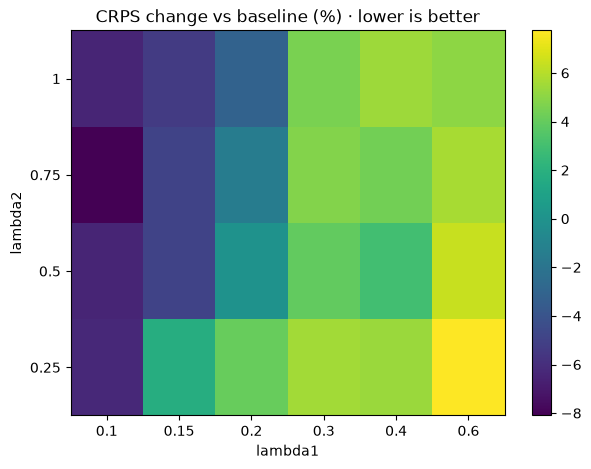

In [15]:
# First-pass recommendation: Minnesota shrinkage only.
# Execute this cell when you are ready to run the model.
gas_screen = run_prior_workflow(
    "gas",
    blocks=("minnesota",),
    mode_name="screen",
)

show_block_result(gas_screen["blocks"]["minnesota"])
plot_two_parameter_surface(gas_screen["blocks"]["minnesota"])

In [16]:
# Optional full prior-block sequence after the Minnesota screen.
# This is intentionally separate because it is much more expensive.
#
# gas_all_blocks = run_prior_workflow(
#     "gas",
#     blocks=(
#         "minnesota",
#         "lag_decay",
#         "constant_scale",
#         "contemporaneous_A",
#         "stochastic_volatility",
#         "initial_volatility",
#         "outliers",
#     ),
#     mode_name="screen",
# )

## 12 · Electricity

Baseline contract is read directly from `energy_bvar_pipeline.MODEL_SPECS`.
The primary scoring variable defaults to `panel.target`.

Start with the Minnesota block. After inspecting it, extend `blocks=` to the
other prior blocks.

In [17]:
electricity_panel = build_panel("electricity", VINTAGE, project_root=PROJECT_ROOT)
display(electricity_panel.describe().to_frame("value"))
print("Baseline missing method:", model_spec("electricity").missing_data_method)
print("Effective missing method:", resolve_missing_method("electricity"))
print("Target scored:", SCORE_VARIABLE_OVERRIDE.get("electricity") or electricity_panel.target)

,value
model_id,electricity
vintage,20260816
dataset,C:\Users\kelyan.gane\Project\Python\Bayesian_m...
frequency,monthly
p,12
variables,"natural_gas_wholesale, electricity_pre_tax"
target,electricity_pre_tax
n_observations,278
sample_start,2003-07-01 00:00:00
sample_end,2026-08-01 00:00:00


Baseline missing method: linear
Effective missing method: linear
Target scored: electricity_pre_tax


[electricity · minnesota · screen] 1/144 | origin=2025-07-01 | {'lambda1': 0.1, 'lambda2': 0.25}
[electricity · minnesota · screen] 2/144 | origin=2025-08-01 | {'lambda1': 0.1, 'lambda2': 0.25}
[electricity · minnesota · screen] 3/144 | origin=2025-09-01 | {'lambda1': 0.1, 'lambda2': 0.25}
[electricity · minnesota · screen] 4/144 | origin=2025-10-01 | {'lambda1': 0.1, 'lambda2': 0.25}
[electricity · minnesota · screen] 5/144 | origin=2025-11-01 | {'lambda1': 0.1, 'lambda2': 0.25}
[electricity · minnesota · screen] 6/144 | origin=2025-12-01 | {'lambda1': 0.1, 'lambda2': 0.25}
[electricity · minnesota · screen] 7/144 | origin=2025-07-01 | {'lambda1': 0.1, 'lambda2': 0.5}
[electricity · minnesota · screen] 8/144 | origin=2025-08-01 | {'lambda1': 0.1, 'lambda2': 0.5}
[electricity · minnesota · screen] 9/144 | origin=2025-09-01 | {'lambda1': 0.1, 'lambda2': 0.5}
[electricity · minnesota · screen] 10/144 | origin=2025-10-01 | {'lambda1': 0.1, 'lambda2': 0.5}
[electricity · minnesota · screen

,candidate__lambda1,candidate__lambda2,mean_crps,crps_vs_baseline_pct,rmse,rmse_vs_baseline_pct,mae,mean_log_score,instability_rejection,n_origins,n_failures
0,0.30,0.50,0.001480,-0.423538,0.002324,-8.067779,0.001793,4.513538,0.0,6,0
1,0.60,0.25,0.001485,-0.091806,0.002569,1.633452,0.001820,4.528951,0.0,6,0
2,0.20,0.50,0.001486,0.000000,0.002528,0.000000,0.001716,4.541806,0.0,6,0
3,0.30,0.25,0.001513,1.802051,0.002474,-2.140711,0.001795,4.514386,0.0,6,0
4,0.15,1.00,0.001521,2.338045,0.002379,-5.882146,0.001619,4.486621,0.0,6,0
5,0.40,0.25,0.001528,2.820624,0.002745,8.595661,0.001851,4.500796,0.0,6,0
6,0.30,1.00,0.001529,2.873008,0.002488,-1.563077,0.001966,4.481581,0.0,6,0
7,0.40,0.50,0.001534,3.250338,0.002489,-1.512704,0.001920,4.497114,0.0,6,0


Best overrides: {'lambda1': np.float64(0.3), 'lambda2': np.float64(0.5)}
Missing-data method: linear
Scored variable: electricity_pre_tax



,candidate__lambda1,candidate__lambda2,mean_crps,crps_vs_baseline_pct,rmse,rmse_vs_baseline_pct,mae,mean_log_score,instability_rejection,n_origins,n_failures
0,0.30,0.50,0.001480,-0.423538,0.002324,-8.067779,0.001793,4.513538,0.000000,6,0
1,0.60,0.25,0.001485,-0.091806,0.002569,1.633452,0.001820,4.528951,0.000000,6,0
2,0.20,0.50,0.001486,0.000000,0.002528,0.000000,0.001716,4.541806,0.000000,6,0
3,0.30,0.25,0.001513,1.802051,0.002474,-2.140711,0.001795,4.514386,0.000000,6,0
4,0.15,1.00,0.001521,2.338045,0.002379,-5.882146,0.001619,4.486621,0.000000,6,0
5,0.40,0.25,0.001528,2.820624,0.002745,8.595661,0.001851,4.500796,0.000000,6,0
6,0.30,1.00,0.001529,2.873008,0.002488,-1.563077,0.001966,4.481581,0.000000,6,0
7,0.40,0.50,0.001534,3.250338,0.002489,-1.512704,0.001920,4.497114,0.000000,6,0
8,0.60,0.50,0.001538,3.509643,0.002831,12.009580,0.002123,4.515520,0.000139,6,0
9,0.10,1.00,0.001546,4.036538,0.002711,7.266342,0.001958,4.491768,0.000000,6,0


Best overrides: {'lambda1': np.float64(0.3), 'lambda2': np.float64(0.5)}
Missing-data method: linear
Scored variable: electricity_pre_tax


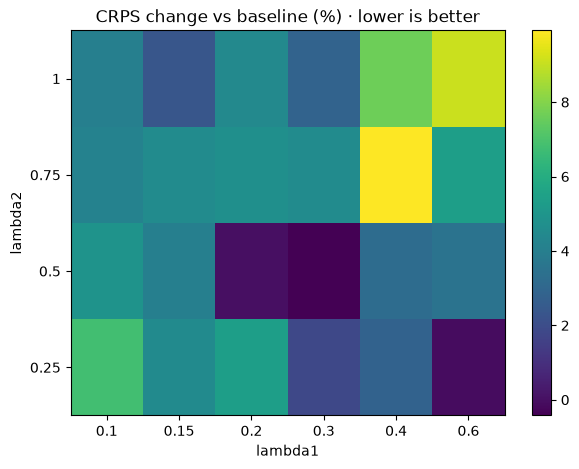

In [18]:
# First-pass recommendation: Minnesota shrinkage only.
# Execute this cell when you are ready to run the model.
electricity_screen = run_prior_workflow(
    "electricity",
    blocks=("minnesota",),
    mode_name="screen",
)

show_block_result(electricity_screen["blocks"]["minnesota"])
plot_two_parameter_surface(electricity_screen["blocks"]["minnesota"])

In [19]:
# Optional full prior-block sequence after the Minnesota screen.
# This is intentionally separate because it is much more expensive.
#
# electricity_all_blocks = run_prior_workflow(
#     "electricity",
#     blocks=(
#         "minnesota",
#         "lag_decay",
#         "constant_scale",
#         "contemporaneous_A",
#         "stochastic_volatility",
#         "initial_volatility",
#         "outliers",
#     ),
#     mode_name="screen",
# )

## 13 · Heat energy

Baseline contract is read directly from `energy_bvar_pipeline.MODEL_SPECS`.
The primary scoring variable defaults to `panel.target`.

Start with the Minnesota block. After inspecting it, extend `blocks=` to the
other prior blocks.

In [20]:
heat_energy_panel = build_panel("heat_energy", VINTAGE, project_root=PROJECT_ROOT)
display(heat_energy_panel.describe().to_frame("value"))
print("Baseline missing method:", model_spec("heat_energy").missing_data_method)
print("Effective missing method:", resolve_missing_method("heat_energy"))
print("Target scored:", SCORE_VARIABLE_OVERRIDE.get("heat_energy") or heat_energy_panel.target)

,value
model_id,heat_energy
vintage,20260816
dataset,C:\Users\kelyan.gane\Project\Python\Bayesian_m...
frequency,monthly
p,12
variables,"natural_gas_wholesale, ppi_energy, hicp_heat_e..."
target,hicp_heat_energy
n_observations,368
sample_start,1996-01-01 00:00:00
sample_end,2026-08-01 00:00:00


Baseline missing method: linear
Effective missing method: linear
Target scored: hicp_heat_energy


[heat_energy · minnesota · screen] 1/144 | origin=2025-07-01 | {'lambda1': 0.1, 'lambda2': 0.25}
[heat_energy · minnesota · screen] 2/144 | origin=2025-08-01 | {'lambda1': 0.1, 'lambda2': 0.25}
[heat_energy · minnesota · screen] 3/144 | origin=2025-09-01 | {'lambda1': 0.1, 'lambda2': 0.25}
[heat_energy · minnesota · screen] 4/144 | origin=2025-10-01 | {'lambda1': 0.1, 'lambda2': 0.25}
[heat_energy · minnesota · screen] 5/144 | origin=2025-11-01 | {'lambda1': 0.1, 'lambda2': 0.25}
[heat_energy · minnesota · screen] 6/144 | origin=2025-12-01 | {'lambda1': 0.1, 'lambda2': 0.25}
[heat_energy · minnesota · screen] 7/144 | origin=2025-07-01 | {'lambda1': 0.1, 'lambda2': 0.5}
[heat_energy · minnesota · screen] 8/144 | origin=2025-08-01 | {'lambda1': 0.1, 'lambda2': 0.5}
[heat_energy · minnesota · screen] 9/144 | origin=2025-09-01 | {'lambda1': 0.1, 'lambda2': 0.5}
[heat_energy · minnesota · screen] 10/144 | origin=2025-10-01 | {'lambda1': 0.1, 'lambda2': 0.5}
[heat_energy · minnesota · screen

,candidate__lambda1,candidate__lambda2,mean_crps,crps_vs_baseline_pct,rmse,rmse_vs_baseline_pct,mae,mean_log_score,instability_rejection,n_origins,n_failures
0,0.10,0.25,0.711458,-13.909429,1.371588,-14.724023,1.020205,-1.609509,0.0,6,0
1,0.15,0.25,0.749305,-9.329667,1.424100,-11.459224,1.101753,-1.621077,0.0,6,0
2,0.10,0.50,0.776283,-6.065247,1.412694,-12.168389,1.111314,-1.655824,0.0,6,0
3,0.20,0.25,0.801671,-2.993103,1.455798,-9.488435,1.153049,-1.712964,0.0,6,0
4,0.20,0.50,0.826406,0.000000,1.608411,0.000000,1.291182,-1.713396,0.0,6,0
5,0.30,0.25,0.837661,1.361927,1.602222,-0.384811,1.260999,-1.716011,0.0,6,0
6,0.15,0.50,0.839126,1.539225,1.592075,-1.015679,1.238941,-1.744211,0.0,6,0
7,0.10,0.75,0.847402,2.540578,1.627219,1.169348,1.313478,-1.737998,0.0,6,0


Best overrides: {'lambda1': np.float64(0.1), 'lambda2': np.float64(0.25)}
Missing-data method: linear
Scored variable: hicp_heat_energy



,candidate__lambda1,candidate__lambda2,mean_crps,crps_vs_baseline_pct,rmse,rmse_vs_baseline_pct,mae,mean_log_score,instability_rejection,n_origins,n_failures
0,0.10,0.25,0.711458,-13.909429,1.371588,-14.724023,1.020205,-1.609509,0.0,6,0
1,0.15,0.25,0.749305,-9.329667,1.424100,-11.459224,1.101753,-1.621077,0.0,6,0
2,0.10,0.50,0.776283,-6.065247,1.412694,-12.168389,1.111314,-1.655824,0.0,6,0
3,0.20,0.25,0.801671,-2.993103,1.455798,-9.488435,1.153049,-1.712964,0.0,6,0
4,0.20,0.50,0.826406,0.000000,1.608411,0.000000,1.291182,-1.713396,0.0,6,0
5,0.30,0.25,0.837661,1.361927,1.602222,-0.384811,1.260999,-1.716011,0.0,6,0
6,0.15,0.50,0.839126,1.539225,1.592075,-1.015679,1.238941,-1.744211,0.0,6,0
7,0.10,0.75,0.847402,2.540578,1.627219,1.169348,1.313478,-1.737998,0.0,6,0
8,0.30,0.50,0.862438,4.360027,1.662178,3.342859,1.311822,-1.715498,0.0,6,0
9,0.10,1.00,0.864088,4.559720,1.638023,1.841024,1.336307,-1.749694,0.0,6,0


Best overrides: {'lambda1': np.float64(0.1), 'lambda2': np.float64(0.25)}
Missing-data method: linear
Scored variable: hicp_heat_energy


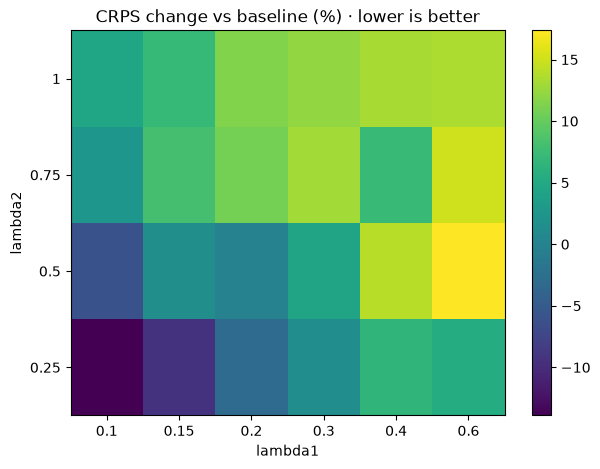

In [21]:
# First-pass recommendation: Minnesota shrinkage only.
# Execute this cell when you are ready to run the model.
heat_energy_screen = run_prior_workflow(
    "heat_energy",
    blocks=("minnesota",),
    mode_name="screen",
)

show_block_result(heat_energy_screen["blocks"]["minnesota"])
plot_two_parameter_surface(heat_energy_screen["blocks"]["minnesota"])

In [22]:
# Optional full prior-block sequence after the Minnesota screen.
# This is intentionally separate because it is much more expensive.
#
# heat_energy_all_blocks = run_prior_workflow(
#     "heat_energy",
#     blocks=(
#         "minnesota",
#         "lag_decay",
#         "constant_scale",
#         "contemporaneous_A",
#         "stochastic_volatility",
#         "initial_volatility",
#         "outliers",
#     ),
#     mode_name="screen",
# )

## 14 · Solid fuels

Baseline contract is read directly from `energy_bvar_pipeline.MODEL_SPECS`.
The primary scoring variable defaults to `panel.target`.

Start with the Minnesota block. After inspecting it, extend `blocks=` to the
other prior blocks.

In [23]:
solid_fuels_panel = build_panel("solid_fuels", VINTAGE, project_root=PROJECT_ROOT)
display(solid_fuels_panel.describe().to_frame("value"))
print("Baseline missing method:", model_spec("solid_fuels").missing_data_method)
print("Effective missing method:", resolve_missing_method("solid_fuels"))
print("Target scored:", SCORE_VARIABLE_OVERRIDE.get("solid_fuels") or solid_fuels_panel.target)

,value
model_id,solid_fuels
vintage,20260816
dataset,C:\Users\kelyan.gane\Project\Python\Bayesian_m...
frequency,monthly
p,12
variables,"natural_gas_wholesale, ppi_energy, hicp_solid_..."
target,hicp_solid_fuels
n_observations,380
sample_start,1995-01-01 00:00:00
sample_end,2026-08-01 00:00:00


Baseline missing method: linear
Effective missing method: linear
Target scored: hicp_solid_fuels


[solid_fuels · minnesota · screen] 1/144 | origin=2025-07-01 | {'lambda1': 0.1, 'lambda2': 0.25}
[solid_fuels · minnesota · screen] 2/144 | origin=2025-08-01 | {'lambda1': 0.1, 'lambda2': 0.25}
[solid_fuels · minnesota · screen] 3/144 | origin=2025-09-01 | {'lambda1': 0.1, 'lambda2': 0.25}
[solid_fuels · minnesota · screen] 4/144 | origin=2025-10-01 | {'lambda1': 0.1, 'lambda2': 0.25}
[solid_fuels · minnesota · screen] 5/144 | origin=2025-11-01 | {'lambda1': 0.1, 'lambda2': 0.25}
[solid_fuels · minnesota · screen] 6/144 | origin=2025-12-01 | {'lambda1': 0.1, 'lambda2': 0.25}
[solid_fuels · minnesota · screen] 7/144 | origin=2025-07-01 | {'lambda1': 0.1, 'lambda2': 0.5}
[solid_fuels · minnesota · screen] 8/144 | origin=2025-08-01 | {'lambda1': 0.1, 'lambda2': 0.5}
[solid_fuels · minnesota · screen] 9/144 | origin=2025-09-01 | {'lambda1': 0.1, 'lambda2': 0.5}
[solid_fuels · minnesota · screen] 10/144 | origin=2025-10-01 | {'lambda1': 0.1, 'lambda2': 0.5}
[solid_fuels · minnesota · screen

,candidate__lambda1,candidate__lambda2,mean_crps,crps_vs_baseline_pct,rmse,rmse_vs_baseline_pct,mae,mean_log_score,instability_rejection,n_origins,n_failures
0,0.60,0.25,1.813033,-1.460460,3.070724,0.703235,2.446266,-2.801940,0.0,6,0
1,0.30,0.25,1.813467,-1.436885,3.038892,-0.340671,2.411465,-3.383126,0.0,6,0
2,0.40,0.25,1.816382,-1.278456,3.039305,-0.327141,2.406351,-2.833330,0.0,6,0
3,0.20,0.25,1.816871,-1.251907,3.057190,0.259413,2.444076,-3.109082,0.0,6,0
4,0.15,0.50,1.826533,-0.726762,3.078867,0.970281,2.462085,-2.903905,0.0,6,0
5,0.40,0.50,1.833421,-0.352382,3.123822,2.444565,2.500736,-2.833370,0.0,6,0
6,0.30,0.75,1.837667,-0.121590,3.190385,4.627490,2.544814,-3.085452,0.0,6,0
7,0.10,0.25,1.838669,-0.067174,3.069704,0.669780,2.459981,-2.874747,0.0,6,0


Best overrides: {'lambda1': np.float64(0.6), 'lambda2': np.float64(0.25)}
Missing-data method: linear
Scored variable: hicp_solid_fuels



,candidate__lambda1,candidate__lambda2,mean_crps,crps_vs_baseline_pct,rmse,rmse_vs_baseline_pct,mae,mean_log_score,instability_rejection,n_origins,n_failures
0,0.60,0.25,1.813033,-1.460460,3.070724,0.703235,2.446266,-2.801940,0.000000,6,0
1,0.30,0.25,1.813467,-1.436885,3.038892,-0.340671,2.411465,-3.383126,0.000000,6,0
2,0.40,0.25,1.816382,-1.278456,3.039305,-0.327141,2.406351,-2.833330,0.000000,6,0
3,0.20,0.25,1.816871,-1.251907,3.057190,0.259413,2.444076,-3.109082,0.000000,6,0
4,0.15,0.50,1.826533,-0.726762,3.078867,0.970281,2.462085,-2.903905,0.000000,6,0
5,0.40,0.50,1.833421,-0.352382,3.123822,2.444565,2.500736,-2.833370,0.000000,6,0
6,0.30,0.75,1.837667,-0.121590,3.190385,4.627490,2.544814,-3.085452,0.000000,6,0
7,0.10,0.25,1.838669,-0.067174,3.069704,0.669780,2.459981,-2.874747,0.000000,6,0
8,0.20,0.50,1.839905,0.000000,3.049280,0.000000,2.447567,-2.793818,0.000000,6,0
9,0.20,1.00,1.840574,0.036371,3.134769,2.803580,2.510841,-2.718820,0.000000,6,0


Best overrides: {'lambda1': np.float64(0.6), 'lambda2': np.float64(0.25)}
Missing-data method: linear
Scored variable: hicp_solid_fuels


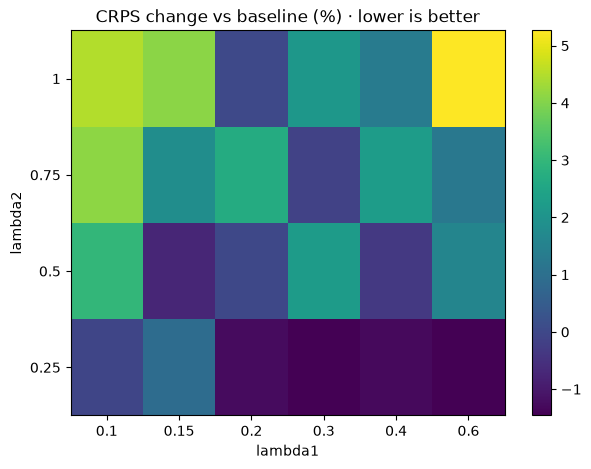

In [24]:
# First-pass recommendation: Minnesota shrinkage only.
# Execute this cell when you are ready to run the model.
solid_fuels_screen = run_prior_workflow(
    "solid_fuels",
    blocks=("minnesota",),
    mode_name="screen",
)

show_block_result(solid_fuels_screen["blocks"]["minnesota"])
plot_two_parameter_surface(solid_fuels_screen["blocks"]["minnesota"])

In [25]:
# Optional full prior-block sequence after the Minnesota screen.
# This is intentionally separate because it is much more expensive.
#
# solid_fuels_all_blocks = run_prior_workflow(
#     "solid_fuels",
#     blocks=(
#         "minnesota",
#         "lag_decay",
#         "constant_scale",
#         "contemporaneous_A",
#         "stochastic_volatility",
#         "initial_volatility",
#         "outliers",
#     ),
#     mode_name="screen",
# )

## 15 · Petrol

Baseline contract is read directly from `energy_bvar_pipeline.MODEL_SPECS`.
The primary scoring variable defaults to `panel.target`.

Start with the Minnesota block. After inspecting it, extend `blocks=` to the
other prior blocks.

In [26]:
car_fuels_petrol_panel = build_panel("car_fuels_petrol", VINTAGE, project_root=PROJECT_ROOT)
display(car_fuels_petrol_panel.describe().to_frame("value"))
print("Baseline missing method:", model_spec("car_fuels_petrol").missing_data_method)
print("Effective missing method:", resolve_missing_method("car_fuels_petrol"))
print("Target scored:", SCORE_VARIABLE_OVERRIDE.get("car_fuels_petrol") or car_fuels_petrol_panel.target)

,value
model_id,car_fuels_petrol
vintage,20260816
dataset,C:\Users\kelyan.gane\Project\Python\Bayesian_m...
frequency,weekly
p,24
variables,"wob_petrol_pre_tax, crude_oil_eur, refined_pet..."
target,wob_petrol_pre_tax
n_observations,1128
sample_start,2005-01-03 00:00:00
sample_end,2026-08-10 00:00:00


Baseline missing method: dk
Effective missing method: dk
Target scored: wob_petrol_pre_tax


In [27]:
# First-pass recommendation: Minnesota shrinkage only.
# Execute this cell when you are ready to run the model.
car_fuels_petrol_screen = run_prior_workflow(
    "car_fuels_petrol",
    blocks=("minnesota",),
    mode_name="screen",
)

show_block_result(car_fuels_petrol_screen["blocks"]["minnesota"])
plot_two_parameter_surface(car_fuels_petrol_screen["blocks"]["minnesota"])

[car_fuels_petrol · minnesota · screen] 1/144 | origin=2025-12-22 | {'lambda1': 0.1, 'lambda2': 0.25}
[car_fuels_petrol · minnesota · screen] 2/144 | origin=2026-01-19 | {'lambda1': 0.1, 'lambda2': 0.25}
[car_fuels_petrol · minnesota · screen] 3/144 | origin=2026-02-16 | {'lambda1': 0.1, 'lambda2': 0.25}
[car_fuels_petrol · minnesota · screen] 4/144 | origin=2026-03-16 | {'lambda1': 0.1, 'lambda2': 0.25}
[car_fuels_petrol · minnesota · screen] 5/144 | origin=2026-04-13 | {'lambda1': 0.1, 'lambda2': 0.25}
[car_fuels_petrol · minnesota · screen] 6/144 | origin=2026-05-11 | {'lambda1': 0.1, 'lambda2': 0.25}
[car_fuels_petrol · minnesota · screen] 7/144 | origin=2025-12-22 | {'lambda1': 0.1, 'lambda2': 0.5}
[car_fuels_petrol · minnesota · screen] 8/144 | origin=2026-01-19 | {'lambda1': 0.1, 'lambda2': 0.5}
[car_fuels_petrol · minnesota · screen] 9/144 | origin=2026-02-16 | {'lambda1': 0.1, 'lambda2': 0.5}
[car_fuels_petrol · minnesota · screen] 10/144 | origin=2026-03-16 | {'lambda1': 0.1,

KeyboardInterrupt: 

In [ ]:
# Optional full prior-block sequence after the Minnesota screen.
# This is intentionally separate because it is much more expensive.
#
# car_fuels_petrol_all_blocks = run_prior_workflow(
#     "car_fuels_petrol",
#     blocks=(
#         "minnesota",
#         "lag_decay",
#         "constant_scale",
#         "contemporaneous_A",
#         "stochastic_volatility",
#         "initial_volatility",
#         "outliers",
#     ),
#     mode_name="screen",
# )

## 16 · Diesel

Baseline contract is read directly from `energy_bvar_pipeline.MODEL_SPECS`.
The primary scoring variable defaults to `panel.target`.

Start with the Minnesota block. After inspecting it, extend `blocks=` to the
other prior blocks.

In [ ]:
car_fuels_diesel_panel = build_panel("car_fuels_diesel", VINTAGE, project_root=PROJECT_ROOT)
display(car_fuels_diesel_panel.describe().to_frame("value"))
print("Baseline missing method:", model_spec("car_fuels_diesel").missing_data_method)
print("Effective missing method:", resolve_missing_method("car_fuels_diesel"))
print("Target scored:", SCORE_VARIABLE_OVERRIDE.get("car_fuels_diesel") or car_fuels_diesel_panel.target)

In [ ]:
# First-pass recommendation: Minnesota shrinkage only.
# Execute this cell when you are ready to run the model.
car_fuels_diesel_screen = run_prior_workflow(
    "car_fuels_diesel",
    blocks=("minnesota",),
    mode_name="screen",
)

show_block_result(car_fuels_diesel_screen["blocks"]["minnesota"])
plot_two_parameter_surface(car_fuels_diesel_screen["blocks"]["minnesota"])

In [ ]:
# Optional full prior-block sequence after the Minnesota screen.
# This is intentionally separate because it is much more expensive.
#
# car_fuels_diesel_all_blocks = run_prior_workflow(
#     "car_fuels_diesel",
#     blocks=(
#         "minnesota",
#         "lag_decay",
#         "constant_scale",
#         "contemporaneous_A",
#         "stochastic_volatility",
#         "initial_volatility",
#         "outliers",
#     ),
#     mode_name="screen",
# )

## 17 · Liquid fuels / heating oil

Baseline contract is read directly from `energy_bvar_pipeline.MODEL_SPECS`.
The primary scoring variable defaults to `panel.target`.

Start with the Minnesota block. After inspecting it, extend `blocks=` to the
other prior blocks.

In [ ]:
liquid_fuels_panel = build_panel("liquid_fuels", VINTAGE, project_root=PROJECT_ROOT)
display(liquid_fuels_panel.describe().to_frame("value"))
print("Baseline missing method:", model_spec("liquid_fuels").missing_data_method)
print("Effective missing method:", resolve_missing_method("liquid_fuels"))
print("Target scored:", SCORE_VARIABLE_OVERRIDE.get("liquid_fuels") or liquid_fuels_panel.target)

In [ ]:
# First-pass recommendation: Minnesota shrinkage only.
# Execute this cell when you are ready to run the model.
liquid_fuels_screen = run_prior_workflow(
    "liquid_fuels",
    blocks=("minnesota",),
    mode_name="screen",
)

show_block_result(liquid_fuels_screen["blocks"]["minnesota"])
plot_two_parameter_surface(liquid_fuels_screen["blocks"]["minnesota"])

In [ ]:
# Optional full prior-block sequence after the Minnesota screen.
# This is intentionally separate because it is much more expensive.
#
# liquid_fuels_all_blocks = run_prior_workflow(
#     "liquid_fuels",
#     blocks=(
#         "minnesota",
#         "lag_decay",
#         "constant_scale",
#         "contemporaneous_A",
#         "stochastic_volatility",
#         "initial_volatility",
#         "outliers",
#     ),
#     mode_name="screen",
# )

# 18 · Cross-model comparison

After running one or more workflows, collect their recommendation records here.
Relative CRPS improvements are meaningful within model; raw CRPS levels should
not be compared across models with different units.

In [ ]:
workflows = {}

# Add completed workflows, for example:
# workflows["gas"] = gas_screen
# workflows["electricity"] = electricity_screen
# workflows["heat_energy"] = heat_energy_screen
# workflows["solid_fuels"] = solid_fuels_screen
# workflows["car_fuels_petrol"] = car_fuels_petrol_screen
# workflows["car_fuels_diesel"] = car_fuels_diesel_screen
# workflows["liquid_fuels"] = liquid_fuels_screen

if workflows:
    recommendations = pd.DataFrame(
        [recommendation_record(w) for w in workflows.values()]
    )
    display(recommendations)
else:
    print("No workflows have been added yet.")

# 19 · Export recommendations

This export is deliberately separate from production configuration. It writes a
research recommendation file under `results/prior_optimisation/` and does **not**
modify `MODEL_SPECS`, dashboard profiles, the registry, or any saved production
run.

In [ ]:
def export_recommendations(workflows: Mapping[str, Mapping]) -> Path:
    if not workflows:
        raise ValueError("No workflows to export.")
    records = [recommendation_record(w) for w in workflows.values()]
    payload = {
        "vintage": str(VINTAGE),
        "method": "recursive pseudo-OOS predictive prior selection",
        "primary_score": "CRPS",
        "note": (
            "GLP-inspired predictive hyperparameter selection applied to the "
            "non-conjugate production BVAR-SV-outlier model; not the closed-form "
            "Normal-Inverse-Wishart marginal likelihood."
        ),
        "models": records,
    }
    path = CACHE_ROOT / "recommended_priors.json"
    path.write_text(json.dumps(payload, indent=2, default=str), encoding="utf-8")
    return path

# Example after adding workflows:
# export_path = export_recommendations(workflows)
# print(export_path)

# 20 · Final validation checklist

Before a prior is promoted to the production dashboard baseline:

1. **Repeat the finalist in `confirm` mode.**
2. **Repeat the final shortlist in `final` mode** with the production Gibbs length.
3. Check that CRPS gains are not concentrated in one single origin.
4. Check RMSE / MAE and log score in addition to CRPS.
5. Check stability rejection and posterior diagnostics.
6. Re-run the structural analysis (IRF / FEVD / HD) with the finalist.
7. For `dk`, inspect DK projection diagnostics and MCMC mixing.
8. For `linear`, remember that interpolation is an approximation and compare the
   finalist to `dk` as a robustness exercise.
9. Do not interpret tiny score differences as economically meaningful when the
   ranking is flat around the optimum.
10. Only after these checks should the dashboard baseline be changed.

## Interpretation of a flat optimum

If several candidates have nearly identical CRPS, the correct conclusion is not
that one decimal-specific hyperparameter is "the true optimum". It is that the
data support a **region** of prior tightness values. In that case, prefer the simpler
or literature-standard point inside the high-performing region.